[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CyrilPitrou/primat/blob/master/notebooks/ReactionRates.ipynb)

# BBN reaction rates vs the Hubble rate

Plots the temperature dependence of the reaction rates that drive BBN, all
expressed as inverse times $[\mathrm{s}^{-1}]$ so they can be compared
directly with the cosmological expansion rate $H(T)$ (black). A reaction is
*efficient* while its rate exceeds $H$ and *freezes out* once it drops below
$H$, so the crossings of each curve with the black line mark the key epochs
of nucleosynthesis.

Two panels:

1. **Weak rates** $n\leftrightarrow p$ (forward $n\to p$ solid, backward
   $p\to n$ dashed). These are already normalised inverse times; their
   crossing with $H$ near $T_\gamma\simeq0.8$ MeV sets the neutron-to-proton
   freeze-out ratio, and $n\to p$ flattens at low $T$ to the free-neutron
   decay rate $1/\tau_n$.
2. **Main nuclear reactions of the `small` network** (forward solid,
   backward dashed, one colour per reaction). The forward rates sit far
   above $H$ (the light network is in nuclear statistical equilibrium),
   while the *backward* photodissociation rates (e.g. $d+\gamma\to n+p$)
   dominate at high $T$ and collapse as the plasma cools — the
   “deuterium bottleneck” that delays nucleosynthesis until
   $T_\gamma\simeq0.07$ MeV.

See PRIMAT's Physics Reports review (Pitrou, Coc, Uzan, Vangioni 2018) for
the definitions of the reaction rates and the weak $n\leftrightarrow p$
rates used here.

In [1]:
import importlib.util, subprocess, sys

# In Colab (or any environment without a local primat checkout), pip-install
# the released package; local dev runs already have it importable (editable
# install / repo on sys.path via the cell below), so this is a no-op there.
if importlib.util.find_spec("primat") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "primat"], check=True)

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from primat.main import PRIMAT
from primat.network_data import reaction_stoichiometry, reaction_display_name
# Figures are written to plots/ next to this notebook; create it so the
# notebook also runs from a fresh clone or on Colab, where it does not exist.
os.makedirs('plots', exist_ok=True)


# A single small-network PRIMAT build gives us everything we need:
#   * run.background -- the cosmological background, exposing the Hubble rate
#     H(T) [s^-1], the baryon mass density rho_B(T) [g/cm^3], and the
#     already-normalised n<->p weak rates [s^-1];
#   * run.nucl._lt_net -- the compiled low-temperature nuclear network, whose
#     fill_buffer(T) returns the forward/backward reaction-rate coefficients
#     (the same ones the ODE right-hand side integrates).
# We only build the background + rate tables here; we never call solve(),
# because these rates are properties of the plasma temperature alone, not of
# a particular abundance history.
# `nucl._lt_net` is internal: unlike run_bbn's result dict it carries no
# stability promise, so a copy of this notebook may need updating if it
# moves. It is the only way to reach the raw rate coefficients.
run = PRIMAT({'network': 'small'})
bg, nucl, cfg = run.background, run.nucl, run.cfg
lt = nucl._lt_net                      # low-T NetworkDefinition
print('Reactions in the small network:', lt.names)

Reactions in the small network: ['n__p', 'n_p__d_g', 'd_p__He3_g', 'd_d__He3_n', 'd_d__t_p', 't_p__a_g', 't_d__a_n', 't_a__Li7_g', 'He3_n__t_p', 'He3_d__a_p', 'He3_a__Be7_g', 'Be7_n__Li7_p', 'Li7_p__a_a']


In [3]:
# Photon-temperature grid, high -> low (MeV). The x-axis is inverted below so
# time flows left -> right (hot early Universe on the left).
T_MeV = np.logspace(np.log10(3.0), np.log10(3e-4), 400)
T_K = T_MeV * cfg.MeV_to_Kelvin


def hubble_of_T(T_MeV):
    """Friedmann expansion rate H(T_gamma) [s^-1] on the temperature grid.

    background.Hubble() needs the three flavour neutrino temperatures as well
    as T_gamma; we read them from the non-instantaneous-decoupling history at
    the cosmic time t(T_gamma) of each grid point (falling back to
    T_nu = T_gamma if no neutrino history is attached).
    """
    H = np.empty_like(T_MeV)
    for i, Tm in enumerate(T_MeV):
        t = float(bg.t_of_T(Tm))
        tnu = bg.Tnu_of_t(t)
        if tnu is None:
            H[i] = bg.Hubble(Tm, Tm, Tm, Tm)
        else:
            H[i] = bg.Hubble(Tm, tnu['e'], tnu['mu'], tnu['tau'])
    return H


# Baryon mass density rho_B(T) [g/cm^3] at each grid point. This is the
# prefactor that converts a nuclear rate *coefficient* into an inverse time
# (see reaction_rate below).
rho_B = np.array([bg.rhoB_BBN(float(bg.t_of_T(Tm))) for Tm in T_MeV])

# Fill the forward/backward rate buffer at every temperature. Layout (see
# NetworkDefinition.fill_buffer): r[0]/r[1] are the weak n->p / p->n rates,
# and for reaction k (>=1) r[2k]/r[2k+1] are its forward/backward coefficient.
# clamp=False keeps the raw detailed-balance reverse rate (no low-T cap), so
# the backward curves are the true physical rates rather than the solver's
# stability-clamped values.
buffers = np.array([
    lt.fill_buffer(tk, bg.weak_nTOp_frwrd, bg.weak_nTOp_bkwrd, clamp=False).copy()
    for tk in T_K])


def weak_rates():
    """(n->p, p->n) weak rates [s^-1] on the grid (already inverse times)."""
    return buffers[:, 0], buffers[:, 1]


def reaction_rate(name):
    """Forward and backward rate of reaction ``name`` as inverse times [s^-1].

    The nuclear network integrates dY_i/dt from fluxes
    F = coeff * rho_B**(n-1) * prod(Y), where n is the number of nuclei on
    that side of the reaction (see primat.network_builder). Because PRIMAT's
    abundances Y are dimensionless number fractions, the group
    ``coeff * rho_B**(n-1)`` already carries units of s^-1: it is exactly the
    reaction-rate coefficient the solver multiplies onto the abundance
    monomial, i.e. the rate per unit reactant fraction. That is what we plot,
    so the comparison with H(T) is apples-to-apples.

    The forward side uses R = number of reactants; the backward side uses
    P = number of products (photons are not counted — they are folded into
    the detailed-balance coefficient), matching the rho powers in the RHS.
    """
    k = lt.names.index(name)
    reactants, products = reaction_stoichiometry(name)
    R, P = sum(reactants.values()), sum(products.values())
    forward = buffers[:, 2 * k] * rho_B ** (R - 1)
    backward = buffers[:, 2 * k + 1] * rho_B ** (P - 1)
    return forward, backward


H = hubble_of_T(T_MeV)

## Weak $n\leftrightarrow p$ rates

The forward $n\to p$ (solid) and backward $p\to n$ (dashed) rates cross the
Hubble line near $T_\gamma\simeq0.8$ MeV: this is weak freeze-out, which
fixes the neutron-to-proton ratio that seeds essentially all the $^4$He.
Below $\sim0.1$ MeV the $n\to p$ curve flattens onto the constant
free-neutron decay rate $1/\tau_n$.

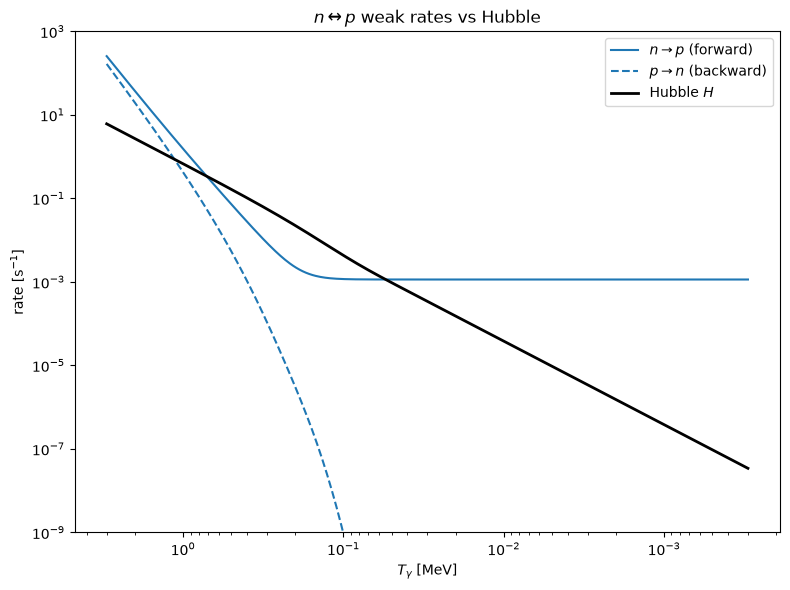

In [4]:
npr, pnr = weak_rates()

fig, ax = plt.subplots(figsize=(8, 6))
ax.loglog(T_MeV, npr, color='C0', ls='-',  label=r'$n\to p$ (forward)')
ax.loglog(T_MeV, pnr, color='C0', ls='--', label=r'$p\to n$ (backward)')
ax.loglog(T_MeV, H,   color='black', lw=2, label=r'Hubble $H$')
ax.invert_xaxis()                      # hot (early) on the left
ax.set_xlabel(r'$T_\gamma$ [MeV]')
ax.set_ylabel(r'rate [s$^{-1}$]')
# Span down to ~1e-9 so the low-T tail is visible: p->n falls far below H,
# while n->p flattens onto the constant free-neutron decay rate 1/tau_n.
ax.set_ylim(1e-9, 1e3)
ax.set_title(r'$n\leftrightarrow p$ weak rates vs Hubble')
ax.legend()
fig.tight_layout()
fig.savefig('plots/reaction_rates_weak.pdf', bbox_inches='tight')
plt.show()

## Main nuclear reactions of the `small` network

Forward rates (solid) and their detailed-balance backward rates (dashed),
one colour per reaction. The forward rates sit orders of magnitude above
$H$ — the light network is in nuclear statistical equilibrium once
deuterium forms — while the backward *photodissociation* rates dominate at
high $T$ (abundant energetic photons) and fall steeply as the plasma cools.
The delay of nucleosynthesis until the backward $d+\gamma\to n+p$ rate drops
below the forward $n+p\to d+\gamma$ rate is the classic *deuterium
bottleneck*.

Set `reactions = lt.names[1:]` to plot all 12 reactions instead of the
curated main channels.

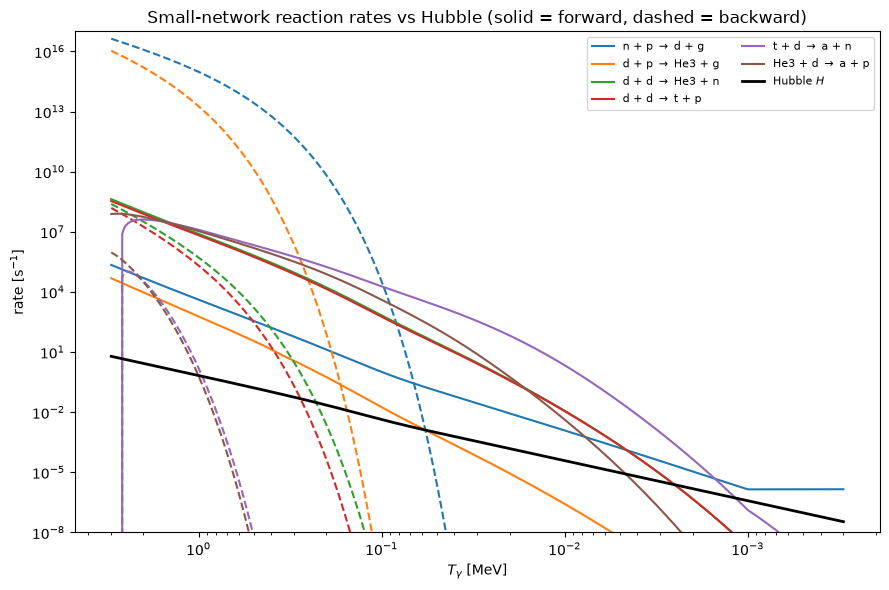

In [5]:
# Curated main channels of the small network (n+p->d and the leading
# deuterium-burning / mass-3 / mass-4 reactions). Swap for lt.names[1:] to
# show all 12 reactions.
reactions = ['n_p__d_g', 'd_p__He3_g', 'd_d__He3_n',
             'd_d__t_p', 't_d__a_n', 'He3_d__a_p']

fig, ax = plt.subplots(figsize=(9, 6))
for j, name in enumerate(reactions):
    forward, backward = reaction_rate(name)
    color = f'C{j}'
    label = reaction_display_name(name).replace(' > ', r' $\to$ ')
    ax.loglog(T_MeV, forward,  color=color, ls='-',  label=label)
    ax.loglog(T_MeV, backward, color=color, ls='--')          # backward: no label
ax.loglog(T_MeV, H, color='black', lw=2, label=r'Hubble $H$')
ax.invert_xaxis()
ax.set_xlabel(r'$T_\gamma$ [MeV]')
ax.set_ylabel(r'rate [s$^{-1}$]')
# Wide y-range: the backward photodissociation rates reach ~1e16 s^-1 when
# the plasma is hot, while H(T) falls to ~1e-6 s^-1 at the end of BBN, so
# span ~1e-8..1e17 to show every curve's full extent and its crossing with H.
ax.set_ylim(1e-8, 1e17)
ax.set_title('Small-network reaction rates vs Hubble '
             '(solid = forward, dashed = backward)')
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig('plots/reaction_rates_nuclear.pdf', bbox_inches='tight')
plt.show()